# Feature Extraction

In [6]:
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from tqdm import tqdm

OUT_DIR = Path("../outputs")
df = pd.read_csv(OUT_DIR / "inventory.csv")
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device :", device, "| images :", len(df))

Device : cpu | images : 1506


In [7]:
weights = ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()   # resize + center crop 224 + normalisation ImageNet
print(preprocess)

model = models.resnet50(weights=weights)
model.fc = nn.Identity()            # on retire la tête de classification -> sortie 2048-d
model.eval().to(device)
for p in model.parameters():        # on gèle tout
    p.requires_grad = False

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Paramètres entraînables :", n_trainable, "(doit être 0)")

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
Paramètres entraînables : 0 (doit être 0)


Choix de la couche d'extraction. Nous extrayons les features à la sortie de la dernière couche convolutionnelle de ResNet50, juste avant la couche fully-connected de classification (remplacée par nn.Identity()), soit un vecteur de 2048 dimensions après global average pooling. Cette couche fournit une représentation visuelle générique et de haut niveau (formes, textures), adaptée au transfert vers un domaine différent d'ImageNet. Les couches plus profondes (la tête FC) sont spécialisées sur les 1000 classes d'ImageNet et donc peu pertinentes pour des IRM ; les couches plus précoces ne capturent que des motifs bas niveau (contours). Le réseau est entièrement gelé : il sert uniquement d'extracteur de features.

In [8]:
class ImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths); self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img)

ds = ImageDataset(df["path"].tolist(), preprocess)
# shuffle=False -> l'ordre des features correspondra exactement aux lignes de df
dl = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)

In [9]:
feats = []
with torch.no_grad():
    for batch in tqdm(dl, desc="Extraction"):
        out = model(batch.to(device))     # (B, 2048)
        feats.append(out.cpu().numpy())

features = np.concatenate(feats, axis=0)
np.save(OUT_DIR / "features.npy", features)

print("Shape features :", features.shape)         # attendu (1506, 2048)
print("Alignées avec df :", features.shape[0] == len(df))
print("NaN ?", np.isnan(features).any(), "| moyenne :", features.mean().round(3),
      "| écart-type :", features.std().round(3))

Extraction: 100%|██████████| 48/48 [00:47<00:00,  1.01it/s]

Shape features : (1506, 2048)
Alignées avec df : True
NaN ? False | moyenne : 0.101 | écart-type : 0.304


Images atypiques : 31 / 1506
split
unlabeled    31
dtype: int64


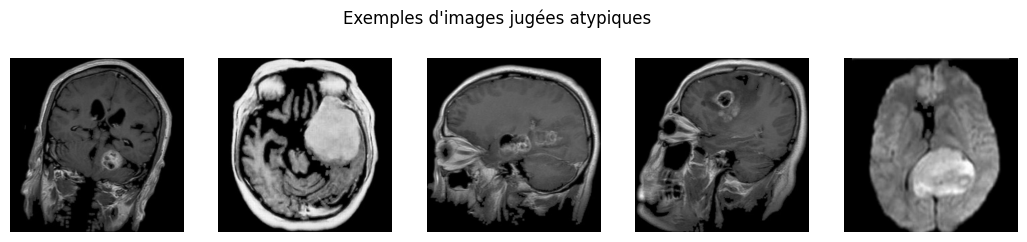

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np, pandas as pd

OUT_DIR = Path("../outputs")
X = np.load(OUT_DIR / "features.npy")
inv = pd.read_csv(OUT_DIR / "inventory.csv")
Xs = StandardScaler().fit_transform(X)

iso = IsolationForest(contamination=0.02, random_state=0)
inv["outlier"] = (iso.fit_predict(Xs) == -1)
print("Images atypiques :", int(inv["outlier"].sum()), "/", len(inv))
print(inv[inv["outlier"]].groupby("split").size())

flagged = inv[inv["outlier"]]["path"].tolist()[:5]
fig, ax = plt.subplots(1, len(flagged), figsize=(2.6*len(flagged), 2.8))
for a, p in zip(ax, flagged):
    a.imshow(Image.open(p)); a.axis("off")
fig.suptitle("Exemples d'images jugées atypiques"); plt.show()

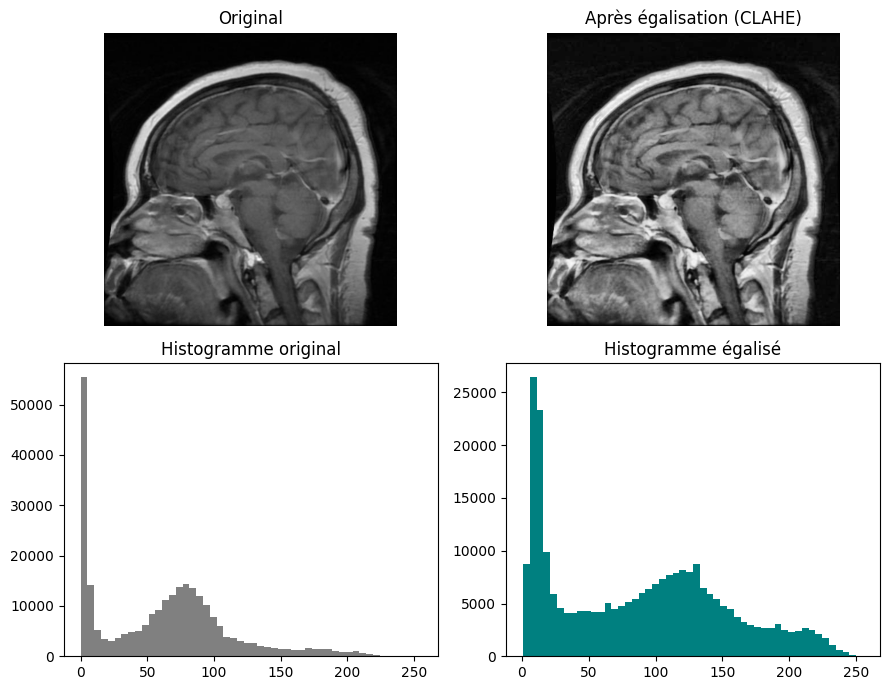

In [1]:
import cv2, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

OUT_DIR = Path("../outputs")
inv = pd.read_csv(OUT_DIR / "inventory.csv")

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
p = inv["path"].iloc[0]
orig = np.array(Image.open(p).convert("L"))
eq = clahe.apply(orig)

fig, ax = plt.subplots(2, 2, figsize=(9, 7))
ax[0,0].imshow(orig, cmap="gray"); ax[0,0].set_title("Original"); ax[0,0].axis("off")
ax[0,1].imshow(eq, cmap="gray"); ax[0,1].set_title("Après égalisation (CLAHE)"); ax[0,1].axis("off")
ax[1,0].hist(orig.ravel(), bins=50, color="gray");  ax[1,0].set_title("Histogramme original")
ax[1,1].hist(eq.ravel(), bins=50, color="teal");    ax[1,1].set_title("Histogramme égalisé")
plt.tight_layout(); plt.show()

In [2]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
weights = ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()
model = models.resnet50(weights=weights); model.fc = nn.Identity(); model.eval().to(device)
for prm in model.parameters(): prm.requires_grad = False

class CLAHEDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths); self.transform = transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        g = self.clahe.apply(np.array(Image.open(self.paths[i]).convert("L")))
        return self.transform(Image.fromarray(g).convert("RGB"))

dl = DataLoader(CLAHEDataset(inv["path"].tolist(), preprocess), batch_size=32, shuffle=False)
feats = []
with torch.no_grad():
    for b in tqdm(dl, desc="Extraction CLAHE"):
        feats.append(model(b.to(device)).cpu().numpy())
features_eq = np.concatenate(feats)
np.save(OUT_DIR / "features_eq.npy", features_eq)
print("features_eq :", features_eq.shape)

Extraction CLAHE: 100%|██████████| 48/48 [00:45<00:00,  1.05it/s]

features_eq : (1506, 2048)


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, roc_auc_score
from sklearn.semi_supervised import LabelSpreading
from sklearn.model_selection import StratifiedShuffleSplit

path2idx = {p: i for i, p in enumerate(inv["path"])}
mask = (inv["split"] == "labeled").to_numpy()
sl = inv[inv["split"] == "labeled"].copy()
sl["y"] = sl["label"].map({"normal": 0, "cancer": 1})
idx_all = np.array([path2idx[p] for p in sl["path"]]); true_all = sl["y"].to_numpy()

def evaluate_features(X, name):
    Xp = PCA(50, random_state=0).fit_transform(StandardScaler().fit_transform(X))
    cl = KMeans(2, n_init=10, random_state=0).fit_predict(Xp)
    ari = adjusted_rand_score(true_all, cl[idx_all])
    aucs = []
    for seed in range(5):
        tr, te = next(StratifiedShuffleSplit(1, test_size=0.3, random_state=seed).split(idx_all, true_all))
        y = np.full(len(inv), -1); y[idx_all[tr]] = true_all[tr]
        m = LabelSpreading(kernel="knn", n_neighbors=12, alpha=0.2, max_iter=60).fit(Xp, y)
        aucs.append(roc_auc_score(true_all[te], m.predict_proba(Xp[idx_all[te]])[:, 1]))
    print(f"{name:18s} | ARI={ari:.3f} | AUC={np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

evaluate_features(np.load(OUT_DIR / "features.npy"),    "Sans égalisation")
evaluate_features(np.load(OUT_DIR / "features_eq.npy"), "Avec égalisation")

Sans égalisation   | ARI=0.124 | AUC=0.947 ± 0.022
Avec égalisation   | ARI=0.224 | AUC=0.975 ± 0.009


Efficacité du processus. L'extraction des 1 506 embeddings prend ~46 s sur CPU (batchs de 32). La matrice de features finale est de taille 1506 × 2048 en float32, soit ≈ 12 Mo en mémoire (1506 × 2048 × 4 octets) — négligeable. Les features sont calculées une seule fois puis sauvegardées (features.npy / features_eq.npy) et rechargées dans les notebooks suivants, ce qui évite tout recalcul coûteux. L'approche reste donc viable même sans GPU.

